# 📊 Loan Default Prediction Project  

## 📝 Problem Statement  

### 📌 Background

Loan defaults are a major challenge for financial institutions, leading to significant financial losses and increased risk exposure. Traditional credit scoring methods often fail to capture hidden patterns in borrower behavior, especially when multiple factors such as income, employment history, and debt-to-income ratio interact in complex ways.

### 🎯 Problem

There is a need for a predictive system that can estimate the likelihood of a borrower defaulting on a loan, while also providing practical financial tools to manage repayment.

### 💡 Proposed Solution

We aim to develop a Loan Default Prediction Dashboard that:

* Takes borrower and loan details as input.

* Uses Machine Learning models (Logistic Regression, Random Forest, Deep Learning) to predict probability of default.

* Provides an interactive amortization schedule to help borrowers visualize repayment plans.

* Sends automated email reminders for upcoming payments.

### ✅ Impact

This system will help:

* Financial institutions reduce credit risk by making informed lending decisions.

* Borrowers better understand their repayment schedules and manage finances.

* Researchers and students explore a practical integration of Finance, Machine Learning, and Data Science.



# 📂 Data Collection  

## 📊 Dataset  
The dataset used in this project has been taken from **Kaggle**, with a usability score of **10.0**, ensuring high quality and reliability.  
We are using this dataset because it contains relevant borrower and loan details (such as income, loan amount, credit score, employment history, and default status), which are essential for building a **Loan Default Prediction Model** and for generating an **amortization schedule**.  

## Data Description
`Number of Records = 255347`


### 🔑 Features (Independent Variables)

The following borrower and loan details will be used as input features:

* LoanID

* Age

* Income

* LoanAmount

* CreditScore (or proxy, e.g., payment history, employment duration)

* MonthsEmployed

* NumCreditLines

* InterestRate

* LoanTerm

* DTIRatio (Debt-to-Income Ratio)

* Education

* EmploymentType

* MaritalStatus

* HasMortgage (Yes/No)

* HasDependents (Yes/No)

* LoanPurpose (e.g., personal, home, auto, education)

* HasCoSigner (Yes/No)

### 🎯 Target Variable (Dependent Variable)

* Default

0 = No Default (Loan paid back successfully)

1 = Default (Loan not repaid / charged off)

# Prepare and Analyze Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
df = pd.read_csv("dataset/loan_data.csv")

# Drop unwanted columns
df.drop(["LoanID","NumCreditLines"], axis=1, inplace=True)

# Quick look at data
print(df.head())
print(df.info())
print(df.describe())

# Check null values
print(df.isnull().sum())





   Age  Income  LoanAmount  CreditScore  MonthsEmployed  InterestRate  \
0   56   85994       50587          520              80         15.23   
1   69   50432      124440          458              15          4.81   
2   46   84208      129188          451              26         21.17   
3   32   31713       44799          743               0          7.07   
4   60   20437        9139          633               8          6.51   

   LoanTerm  DTIRatio    Education EmploymentType MaritalStatus HasMortgage  \
0        36      0.44   Bachelor's      Full-time      Divorced         Yes   
1        60      0.68     Master's      Full-time       Married          No   
2        24      0.31     Master's     Unemployed      Divorced         Yes   
3        24      0.23  High School      Full-time       Married          No   
4        48      0.73   Bachelor's     Unemployed      Divorced          No   

  HasDependents LoanPurpose HasCoSigner  Default  
0           Yes       Other        

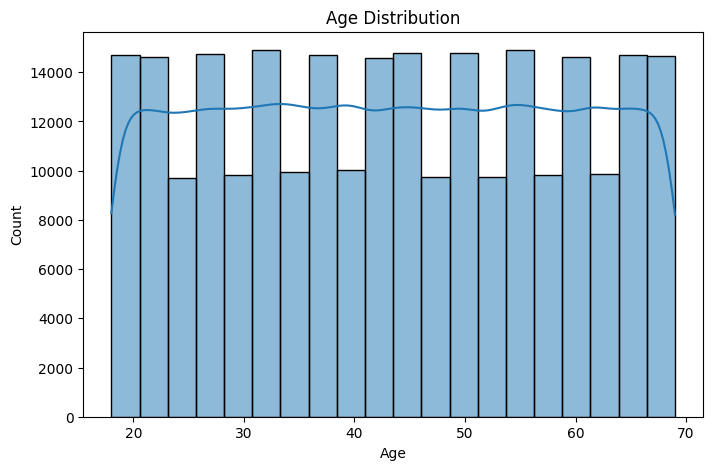

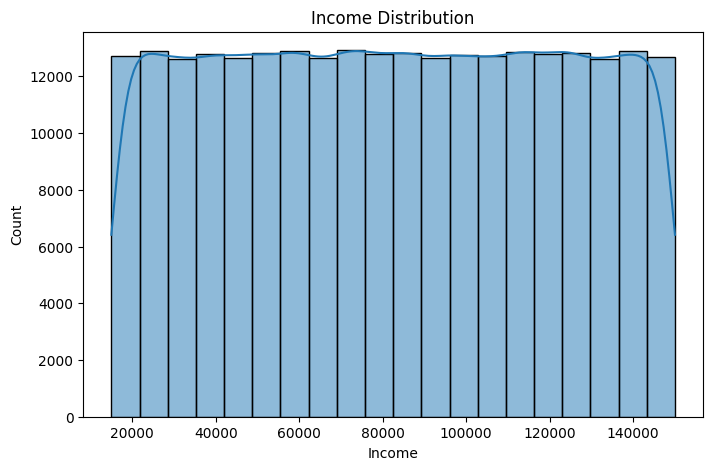

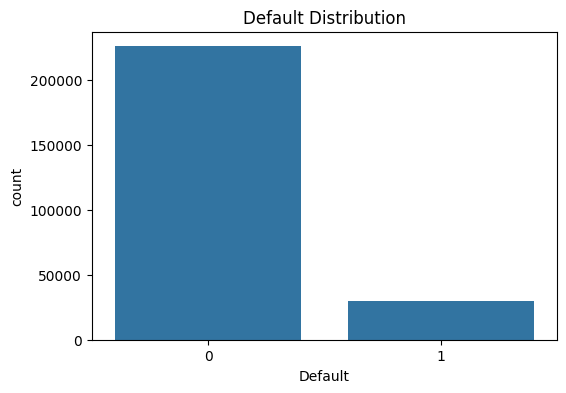

In [2]:
# Quick EDA
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.savefig("assets/age_distribution.png")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Income"], bins=20, kde=True)
plt.title("Income Distribution")
plt.savefig("assets/income_distribution.png")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Default", data=df)
plt.title("Default Distribution")
plt.savefig("assets/default_distribution.png")
plt.show()

# Preprocess Data

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pickle

# Copy dataframe to avoid modifying original
df_processed = df.copy()

# ✅ Map binary categorical columns to 0/1
binary_map = {"Yes": 1, "No": 0, True: 1, False: 0}
for col in ["HasMortgage", "HasDependents", "HasCoSigner"]:
    df_processed[col] = df_processed[col].map(binary_map)

# Separate features and target
X = df_processed.drop("Default", axis=1)
y = df_processed["Default"]

# Define feature groups
ordinal_cols = ["Education"]    # education = ordinal
onehot_cols = ["EmploymentType", "MaritalStatus", "LoanPurpose"]
numeric_cols = [col for col in X.columns if col not in ordinal_cols + onehot_cols + ["Default"]]

print("Numeric columns:", numeric_cols)
print("Ordinal columns:", ordinal_cols)
print("One-hot columns:", onehot_cols)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", OrdinalEncoder(), ordinal_cols),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_cols),
        ("scale", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)

# Full pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit pipeline
pipeline.fit(X_train, y_train)

# Save pipeline
with open("loan_default_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ Pipeline (with preprocessing + model) saved as loan_default_pipeline.pkl")


Numeric columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner']
Ordinal columns: ['Education']
One-hot columns: ['EmploymentType', 'MaritalStatus', 'LoanPurpose']
✅ Pipeline (with preprocessing + model) saved as loan_default_pipeline.pkl


# Select Correct Model


In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Candidate models (all wrapped in pipeline)
models = {
    "LogisticRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ])
}


In [10]:
from sklearn.model_selection import cross_validate

# Evaluate
results = {}
for name, model in models.items():
    scores = cross_validate(
        model, X, y,
        cv=3,                         # fewer folds = faster
        scoring=["f1", "roc_auc"],    # both metrics in one run
        n_jobs=-1,                    # parallelize across CPU cores
        return_train_score=False
    )
    results[name] = {
        "f1": round(scores["test_f1"].mean(), 3),
        "roc_auc": round(scores["test_roc_auc"].mean(), 3)
    }

print("Model comparison:", results)


Model comparison: {'LogisticRegression': {'f1': np.float64(0.062), 'roc_auc': np.float64(0.746)}, 'RandomForest': {'f1': np.float64(0.065), 'roc_auc': np.float64(0.734)}}


# Train ML Model


In [12]:
# Pick the best model (based on comparison above)
best_model_name = max(results, key=lambda k: results[k]["roc_auc"])
print(f"✅ Best model selected: {best_model_name}")

# Refit best model on the full training set
final_model = models[best_model_name]
final_model.fit(X_train, y_train)


✅ Best model selected: LogisticRegression


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinal', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.60      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.74      0.51      0.50     51070
weighted avg       0.85      0.89      0.84     51070



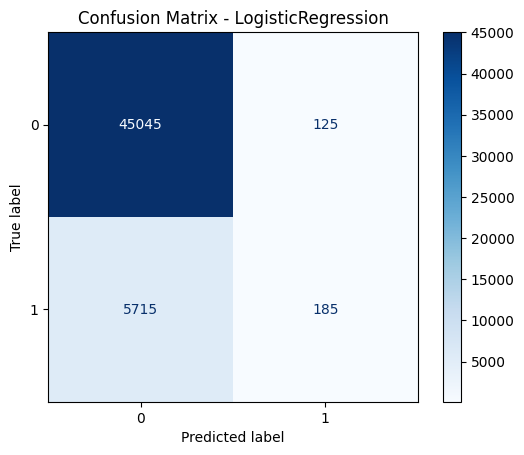

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1] if hasattr(final_model, "predict_proba") else None

# Evaluation Report
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("assets/confusion_matrix.png")
plt.show()


In [14]:
# Save the final model pipeline (preprocessing + model)
with open("loan_default_pipeline.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ Final model saved as loan_default_pipeline.pkl")

# Example: test prediction on new sample
sample = X_test.iloc[0:1]  # take 1 test row
print("🔍 Sample input:")
print(sample)

pred = final_model.predict(sample)
print("🔮 Predicted Default:", pred[0])


✅ Final model saved as loan_default_pipeline.pkl
🔍 Sample input:
       Age  Income  LoanAmount  CreditScore  MonthsEmployed  InterestRate  \
51139   55  112656       92393          581             113         23.54   

       LoanTerm  DTIRatio Education EmploymentType MaritalStatus  HasMortgage  \
51139        36      0.15       PhD  Self-employed        Single            1   

       HasDependents LoanPurpose  HasCoSigner  
51139              1        Home            0  
🔮 Predicted Default: 0
